# Домашнє завдання 09. Персептрон, MLP і backpropagation
    Дата заняття: 19.06.2026 (пт)
    Модуль: Модуль 4. Основи нейронних мереж

### Мета


Побудувати найпростішу нейронну модель у PyTorch через nn.Linear(1, 1), навчити її на регресійній задачі та проаналізувати, як змінюються параметри моделі й значення loss.

### Завдання
Створити notebook homework_08_linear_pytorch.ipynb.

### Проста лінійна модель у PyTorch
##### Контекст
Уявіть, що потрібно побудувати дуже просту модель, яка за одним числовим показником робить числовий прогноз. Завдання - не використати готову модель зі scikit-learn, а самостійно реалізувати мінімальний PyTorch workflow: дані у вигляді тензорів, модель nn.Linear(1, 1), loss, optimizer і навчання.

## Завдання

1. Створіть невеликий синтетичний набір даних з однією ознакою X і цільовим значенням y. Залежність має бути лінійною, наприклад y = 2x + 1 або близькою до неї.
2. Перетворіть дані на PyTorch tensors і перевірте, що форми X та y підходять для nn.Linear(1, 1).
3. Побудуйте модель nn.Linear(1, 1).
4. Виведіть параметри моделі до навчання.
5. Навчіть модель на створених даних:
    - використайте MSE як функцію втрат;
    - використайте SGD або інший простий optimizer;
    - самостійно реалізуйте навчальний цикл.
6. афіксуйте значення loss під час навчання і покажіть, як воно змінюється.
7. Виведіть параметри моделі після навчання та порівняйте їх з очікуваними коефіцієнтами вашої лінійної залежності.
8. Побудуйте графік loss за епохами.
9. Побудуйте графік, на якому видно реальні точки та прогноз моделі.
10. Зробіть короткий висновок:
    - чи навчилася модель відтворювати залежність;
    - що сталося з loss;
    - як змінилися weight і bias;
    - яку роль у навчанні відіграє loss.backward().


##### Що здати
    Файл homework_08_linear_pytorch.ipynb.

In [33]:
import torch
from torch import nn       
import torch.optim as optim 


torch.manual_seed(42)

X = torch.rand(100, 1)
y = 2 * X + 1 + 0.1 * torch.randn(100, 1)

model = nn.Linear(1, 1)
loss_fn = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

print("Параметри моделі до навчання:")
print(f"Нахил прямої: {model.weight.item()}")
print(f"Зсув точки претину з віссю y: {model.bias.item()}")
 
loss_history = []

for epoch in range(200):
    y_pred = model(X)
    loss = loss_fn(y_pred, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    print(f"Епоха {epoch+1}, Loss: {loss.item()}")
    loss_history.append(loss.item())

print() 
print("Параметри моделі ПІСЛЯ навчання:")
print(f"Нахил прямої: {model.weight.item()}")
print(f"Зсув точки претину з віссю y: {model.bias.item()}")
        

Параметри моделі до навчання:
Нахил прямої: 0.14465749263763428
Зсув точки претину з віссю y: -0.2589707374572754
Епоха 1, Loss: 5.195178985595703
Епоха 2, Loss: 2.8968796730041504
Епоха 3, Loss: 1.6275066137313843
Епоха 4, Loss: 0.9261268377304077
Епоха 5, Loss: 0.5383021831512451
Епоха 6, Loss: 0.32357966899871826
Епоха 7, Loss: 0.20442818105220795
Епоха 8, Loss: 0.13804903626441956
Епоха 9, Loss: 0.10081689059734344
Епоха 10, Loss: 0.07968971878290176
Епоха 11, Loss: 0.06746789813041687
Епоха 12, Loss: 0.060176782310009
Епоха 13, Loss: 0.055621881037950516
Епоха 14, Loss: 0.05259149894118309
Епоха 15, Loss: 0.05041635036468506
Епоха 16, Loss: 0.048726633191108704
Епоха 17, Loss: 0.047317877411842346
Епоха 18, Loss: 0.04607684537768364
Епоха 19, Loss: 0.04494071006774902
Епоха 20, Loss: 0.043874457478523254
Епоха 21, Loss: 0.04285844415426254
Епоха 22, Loss: 0.0418815091252327
Епоха 23, Loss: 0.04093719646334648
Епоха 24, Loss: 0.04002164676785469
Епоха 25, Loss: 0.039132457226514816

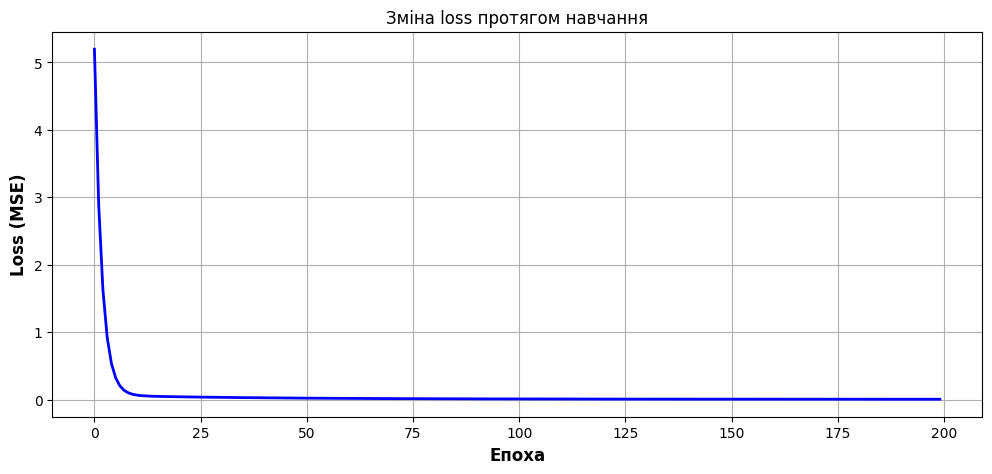

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(loss_history, color='blue', linewidth=2)

plt.title('Зміна loss протягом навчання')
plt.xlabel('Епоха', fontsize=12, fontweight='bold')
plt.ylabel('Loss (MSE)', fontsize=12, fontweight='bold')
plt.grid(True)
plt.show()


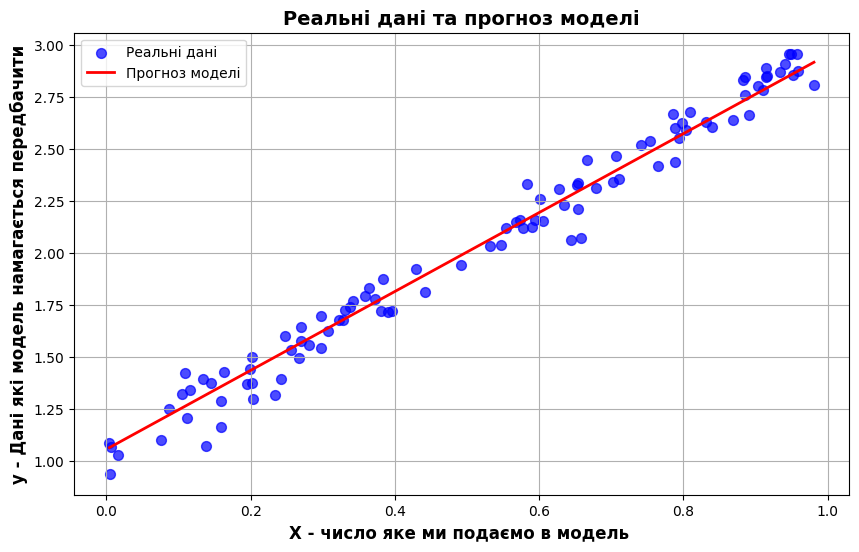

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(X.numpy(), y.numpy(), alpha=0.7, color='blue', marker='o', s=50, label='Реальні дані')
with torch.no_grad():
    X_sorted = torch.sort(X, dim=0)[0]
    y_pred_sorted = model(X_sorted)
    plt.plot(X_sorted.numpy(), y_pred_sorted.numpy(), color='red', linewidth=2, label='Прогноз моделі')

plt.xlabel('X - число яке ми подаємо в модель ', fontsize=12, fontweight='bold')
plt.ylabel('y - Дані які модель намагається передбачити', fontsize=12, fontweight='bold') 

plt.title('Реальні дані та прогноз моделі', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True)
plt.show()


- відповідно до останнбого графіка модель навчилася, така як червона лінія прогнозу проходить через сині точки реальних даних

- loss значно зменшився протягом навчання, про що свідчить перший графік.

- після навчання weight і bias наблизилися до істиних значень, тобто це говорить про начання моделі.

- loss.backward() - показує в яку сторону потрібно рухатись для зменшення помилки.